In [3]:
# ==============================
# XGBOOST BIAS CORRECTION (FINAL - LOW OVERFITTING + CORRECT EVALUATION)
# ==============================

import os
import numpy as np
import pandas as pd

from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# --------------------------------------------------
# 1. LOAD DATA
# --------------------------------------------------
data_dir = r"C:\Users\geri geri\Desktop\prepicitation riability\TM proposal\data"
excel_file = os.path.join(data_dir, "all chirps vs station.xlsx")

df = pd.read_excel(excel_file)

# --------------------------------------------------
# 2. SORT + STATION STRUCTURE
# --------------------------------------------------
df = df.sort_values("number").reset_index(drop=True)

n_years = 27
samples_per_station = n_years * 12

df["station_id"] = df.index // samples_per_station

# --------------------------------------------------
# 3. FEATURE ENGINEERING
# --------------------------------------------------
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

df["chirps_lag1"] = df.groupby("station_id")["chirps_precip"].shift(1)
df["chirps_lag12"] = df.groupby("station_id")["chirps_precip"].shift(12)

df = df.dropna().reset_index(drop=True)

# --------------------------------------------------
# 4. FEATURES / TARGET
# --------------------------------------------------
features = [
    "chirps_precip",
    "month_sin",
    "month_cos",
    "chirps_lag1",
    "chirps_lag12"
]

X = df[features]
y = df["station_precip"]

# --------------------------------------------------
# 5. TRAIN / TEST SPLIT (TIME-BASED)
# --------------------------------------------------
train_size = 22 * 12

train_list = []
test_list = []

for sid in df["station_id"].unique():
    station_df = df[df["station_id"] == sid]
    
    train_list.append(station_df.iloc[:train_size])
    test_list.append(station_df.iloc[train_size:])

df_train = pd.concat(train_list)
df_test = pd.concat(test_list)

X_train = df_train[features]
y_train = df_train["station_precip"]

X_test = df_test[features]
y_test = df_test["station_precip"]

print("Train samples:", len(X_train))
print("Test samples :", len(X_test))

# --------------------------------------------------
# 6. MODEL (XGBOOST - REGULARIZED)
# --------------------------------------------------
tscv = TimeSeriesSplit(n_splits=5)

xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

# 🔥 Strong anti-overfitting grid
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 4, 5],              # shallow trees = less overfit
    "learning_rate": [0.01, 0.05, 0.1],  # slow learning = stable
    "subsample": [0.7, 0.8],             # row sampling
    "colsample_bytree": [0.7, 0.8],      # feature sampling
    "min_child_weight": [3, 5, 10]       # regularization
}

grid = GridSearchCV(
    xgb,
    param_grid,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

best_xgb = grid.best_estimator_

print("\nBEST PARAMETERS:")
print(grid.best_params_)

# --------------------------------------------------
# 7. BIAS CORRECTION
# --------------------------------------------------
df_test["corrected_chirps"] = np.clip(best_xgb.predict(X_test), 0, None)

# --------------------------------------------------
# 8. DRY DAY CORRECTION
# --------------------------------------------------
df_test["corrected_chirps"] = np.where(
    df_test["chirps_precip"] < 1,
    0,
    df_test["corrected_chirps"]
)

# --------------------------------------------------
# 9. PERFORMANCE COMPARISON
# --------------------------------------------------

print("\n===== BEFORE CORRECTION (RAW CHIRPS) =====")
print("R²   :", r2_score(y_test, df_test["chirps_precip"]))
print("RMSE :", np.sqrt(mean_squared_error(y_test, df_test["chirps_precip"])))
print("MAE  :", mean_absolute_error(y_test, df_test["chirps_precip"]))

print("\n===== AFTER CORRECTION (XGBOOST) =====")
print("R²   :", r2_score(y_test, df_test["corrected_chirps"]))
print("RMSE :", np.sqrt(mean_squared_error(y_test, df_test["corrected_chirps"])))
print("MAE  :", mean_absolute_error(y_test, df_test["corrected_chirps"]))

# --------------------------------------------------
# 10. OUTPUT DATASET
# --------------------------------------------------
output = df_test[[
    "station_precip",
    "chirps_precip",
    "corrected_chirps",
    "month",
    "station_id"
]]

print("\nSample Output:")
print(output.head())

Train samples: 2376
Test samples : 432
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

BEST PARAMETERS:
{'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 10, 'n_estimators': 100, 'subsample': 0.8}

===== BEFORE CORRECTION (RAW CHIRPS) =====
R²   : 0.6465885129710138
RMSE : 76.86146332173362
MAE  : 43.85764883603704

===== AFTER CORRECTION (XGBOOST) =====
R²   : 0.7131101534930506
RMSE : 69.25097732128265
MAE  : 40.68344593246778

Sample Output:
     station_precip  chirps_precip  corrected_chirps  month  station_id
264             0.0       0.000000          0.000000      1           0
265             0.0       0.000000          0.000000      2           0
266             1.0      14.368457         19.922449      3           0
267            32.7      51.751168         47.196171      4           0
268           207.9     149.010549        174.789062      5           0


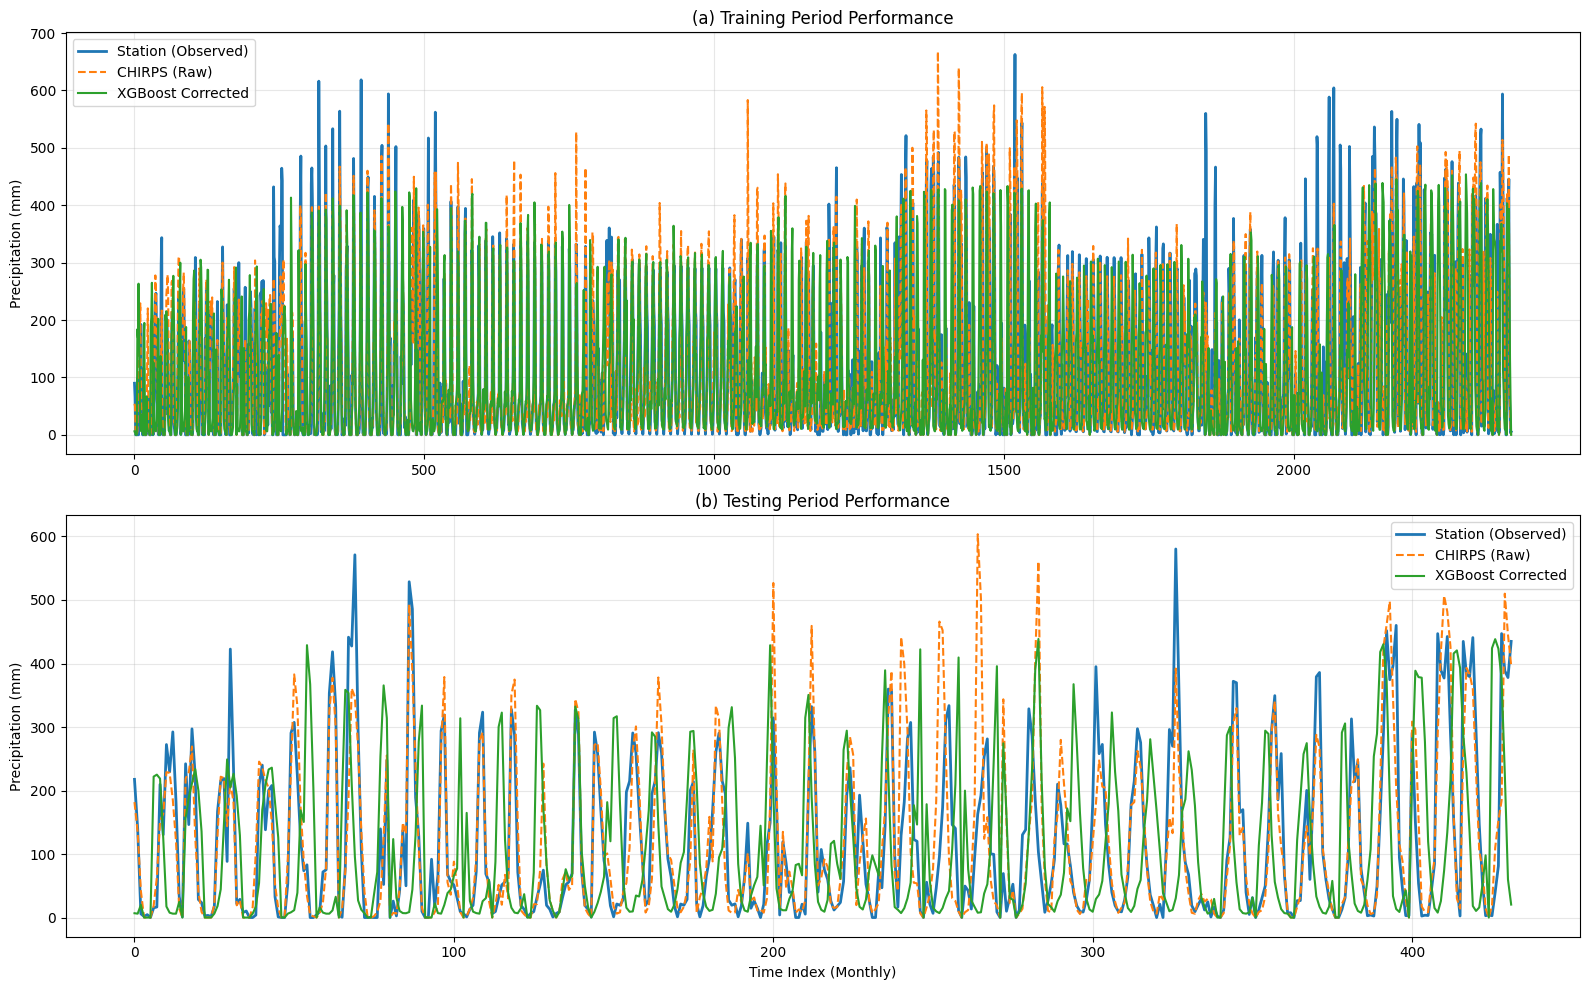

In [6]:
# ==============================
# XGBOOST PUBLICATION PLOT (a) TRAIN (b) TEST
# ==============================

import matplotlib.pyplot as plt
import numpy as np

# --------------------------------------------------
# 1. PREDICTIONS
# --------------------------------------------------
df_train["corrected_chirps"] = np.clip(best_xgb.predict(X_train), 0, None)
df_test["corrected_chirps"] = np.clip(best_xgb.predict(X_test), 0, None)

# Dry-day correction
df_train["corrected_chirps"] = np.where(
    df_train["chirps_precip"] < 1,
    0,
    df_train["corrected_chirps"]
)

df_test["corrected_chirps"] = np.where(
    df_test["chirps_precip"] < 1,
    0,
    df_test["corrected_chirps"]
)

# --------------------------------------------------
# 2. INDEXING (IMPORTANT FIX)
# --------------------------------------------------
df_train = df_train.copy()
df_test = df_test.copy()

df_train["time_index"] = np.arange(len(df_train))
df_test["time_index"] = np.arange(len(df_test))

# --------------------------------------------------
# 3. FIGURE
# --------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=False)

# =========================
# (a) TRAINING
# =========================
axes[0].plot(df_train["time_index"], df_train["station_precip"],
             label="Station (Observed)", linewidth=2)

axes[0].plot(df_train["time_index"], df_train["chirps_precip"],
             linestyle="--", label="CHIRPS (Raw)")

axes[0].plot(df_train["time_index"], df_train["corrected_chirps"],
             label="XGBoost Corrected")

axes[0].set_title("(a) Training Period Performance")
axes[0].set_ylabel("Precipitation (mm)")
axes[0].legend()
axes[0].grid(alpha=0.3)

# =========================
# (b) TESTING
# =========================
axes[1].plot(df_test["time_index"], df_test["station_precip"],
             label="Station (Observed)", linewidth=2)

axes[1].plot(df_test["time_index"], df_test["chirps_precip"],
             linestyle="--", label="CHIRPS (Raw)")

axes[1].plot(df_test["time_index"], df_test["corrected_chirps"],
             label="XGBoost Corrected")

axes[1].set_title("(b) Testing Period Performance")
axes[1].set_xlabel("Time Index (Monthly)")
axes[1].set_ylabel("Precipitation (mm)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
import os
import numpy as np
import rasterio
from tqdm import tqdm

# --------------------------------------------------
# PATHS
# --------------------------------------------------
input_dir = r"C:\Users\geri geri\Desktop\prepicitation riability\TM proposal\data\CHIRPS_Monthly_Abay"
output_dir = os.path.join(input_dir, "XGBOOST_corrected")
os.makedirs(output_dir, exist_ok=True)

# --------------------------------------------------
# SORT FILES BY TIME
# --------------------------------------------------
files = sorted([
    f for f in os.listdir(input_dir)
    if f.endswith(".tif")
])

# --------------------------------------------------
# STORAGE FOR LAGS
# --------------------------------------------------
prev1 = None   # lag-1
prev12 = None  # lag-12

# --------------------------------------------------
# LOOP OVER TIME
# --------------------------------------------------
for i, file in tqdm(enumerate(files), total=len(files)):

    path = os.path.join(input_dir, file)

    # extract YYYYMM
    date_str = file.split("_")[2]
    year = int(date_str[:4])
    month = int(date_str[4:6])

    # seasonal features
    month_sin = np.sin(2 * np.pi * month / 12)
    month_cos = np.cos(2 * np.pi * month / 12)

    with rasterio.open(path) as src:
        profile = src.profile
        chirps = src.read(1).astype(np.float32)

        # handle nodata
        chirps = np.where(chirps < 0, np.nan, chirps)

    # --------------------------------------------------
    # BUILD FEATURE STACK
    # --------------------------------------------------
    rows, cols = chirps.shape

    chirps_flat = chirps.flatten()

    # lag features
    if prev1 is None:
        lag1 = np.zeros_like(chirps_flat)
    else:
        lag1 = prev1

    if prev12 is None:
        lag12 = np.zeros_like(chirps_flat)
    else:
        lag12 = prev12

    # replicate seasonal features
    m_sin = np.full_like(chirps_flat, month_sin)
    m_cos = np.full_like(chirps_flat, month_cos)

    # create feature matrix
    X = np.column_stack([
        chirps_flat,
        m_sin,
        m_cos,
        lag1,
        lag12
    ])

    # --------------------------------------------------
    # PREDICT (ONLY VALID PIXELS)
    # --------------------------------------------------
    valid_mask = ~np.isnan(chirps_flat)

    preds = np.zeros_like(chirps_flat)
    preds[:] = np.nan

    preds[valid_mask] = best_xgb.predict(X[valid_mask])

    preds = np.clip(preds, 0, None)
    preds = preds.reshape(rows, cols)

    # --------------------------------------------------
    # SAVE OUTPUT TIFF
    # --------------------------------------------------
    out_path = os.path.join(output_dir, f"XGBOOST_corrected_{file.split('_')[2]}.tif")

    profile.update(dtype=rasterio.float32)

    with rasterio.open(out_path, "w", **profile) as dst:
        dst.write(preds.astype(np.float32), 1)

    # --------------------------------------------------
    # UPDATE LAGS
    # --------------------------------------------------
    prev12 = prev1.copy() if prev1 is not None else np.zeros_like(chirps_flat)
    prev1 = chirps_flat.copy()

print("DONE: All CHIRPS rasters corrected with XGBoost")

100%|██████████| 420/420 [00:30<00:00, 13.79it/s]

DONE: All CHIRPS rasters corrected with XGBoost


### 1. Single month spatial visualization (publication figure)

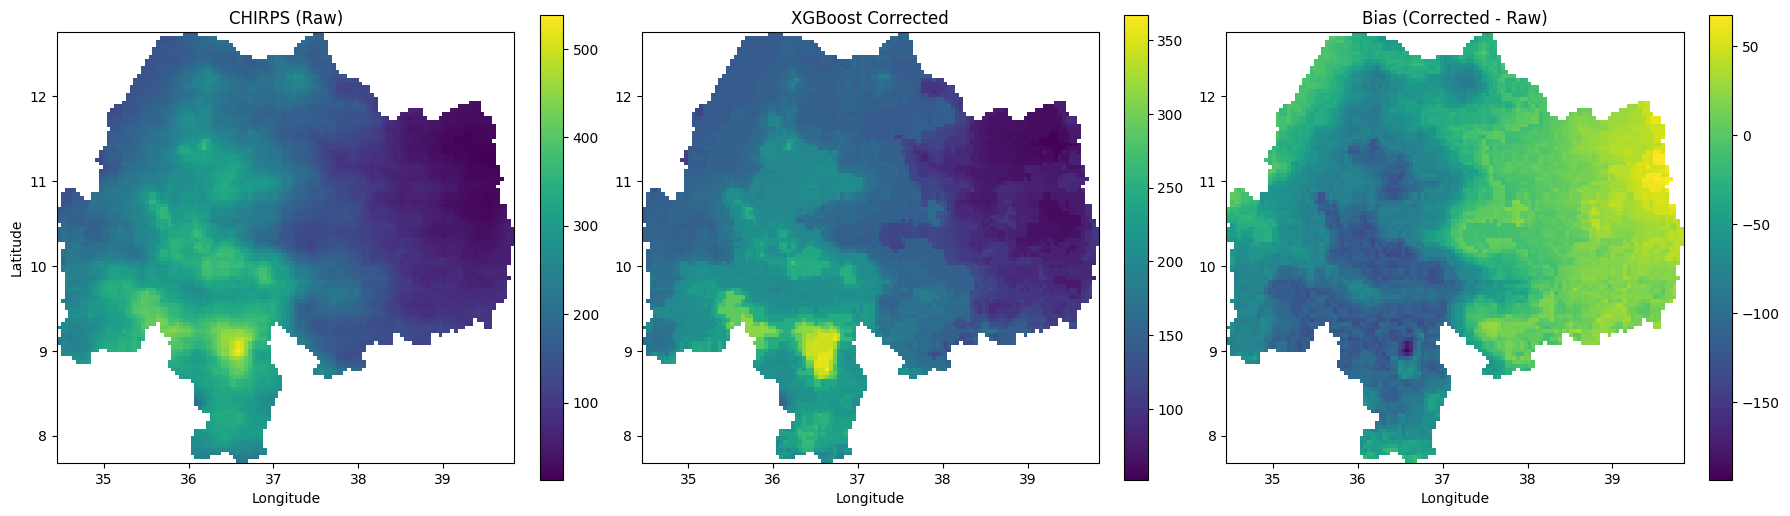

In [13]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import os

input_dir = r"C:\Users\geri geri\Desktop\prepicitation riability\TM proposal\data\CHIRPS_Monthly_Abay"
corr_dir  = os.path.join(input_dir, "XGBOOST_corrected")

file_name = "CHIRPS_Abay_200506_MonthlySum.tif"

raw_path = os.path.join(input_dir, file_name)
corr_path = os.path.join(corr_dir, "XGBOOST_corrected_200506.tif")

# -----------------------------
# READ RASTERS + TRANSFORM
# -----------------------------
with rasterio.open(raw_path) as src:
    chirps = src.read(1)
    transform = src.transform
    crs = src.crs

with rasterio.open(corr_path) as src:
    corrected = src.read(1)

bias = corrected - chirps

# -----------------------------
# FUNCTION: GET GEOGRAPHIC EXTENT
# -----------------------------
def get_extent(transform, width, height):
    left = transform.c
    top = transform.f
    right = transform.c + transform.a * width
    bottom = transform.f + transform.e * height
    return [left, right, bottom, top]

extent = get_extent(transform, chirps.shape[1], chirps.shape[0])

# -----------------------------
# PLOT (WITH GEO AXIS)
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

im0 = axes[0].imshow(chirps, extent=extent, origin="upper")
axes[0].set_title("CHIRPS (Raw)")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(corrected, extent=extent, origin="upper")
axes[1].set_title("XGBoost Corrected")
axes[1].set_xlabel("Longitude")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(bias, extent=extent, origin="upper")
axes[2].set_title("Bias (Corrected - Raw)")
axes[2].set_xlabel("Longitude")
plt.colorbar(im2, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.show()

### spatial biased reduction map

C:\Users\geri geri\AppData\Local\Temp\ipykernel_9148\2231294049.py:18: RuntimeWarning: Mean of empty slice
  bias_mean = np.nanmean(bias_stack, axis=0)


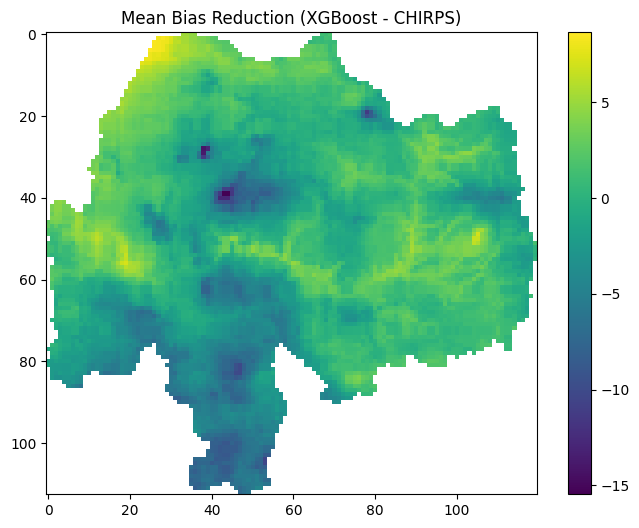

In [9]:
import glob

raw_files = sorted(glob.glob(input_dir + "/*.tif"))
corr_files = sorted(glob.glob(corr_dir + "/*.tif"))

bias_stack = []

for raw_f, corr_f in zip(raw_files, corr_files):

    with rasterio.open(raw_f) as src:
        raw = src.read(1).astype(float)

    with rasterio.open(corr_f) as src:
        corr = src.read(1).astype(float)

    bias_stack.append(corr - raw)

bias_mean = np.nanmean(bias_stack, axis=0)

plt.figure(figsize=(8,6))
plt.imshow(bias_mean)
plt.title("Mean Bias Reduction (XGBoost - CHIRPS)")
plt.colorbar()
plt.show()

### 3. MONTHLY CLIMATOLOGY (BEFORE vs AFTER)

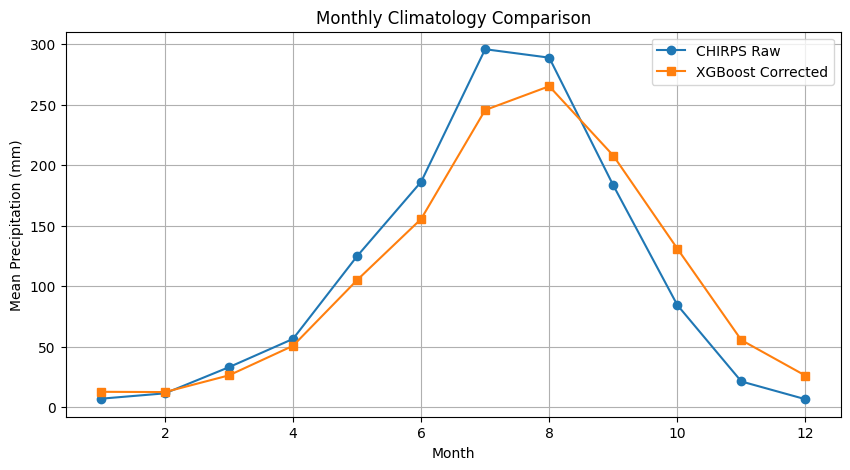

In [11]:
import os
import rasterio
import numpy as np
import matplotlib.pyplot as plt

raw_monthly = {m: [] for m in range(1, 13)}
corr_monthly = {m: [] for m in range(1, 13)}

for raw_f, corr_f in zip(raw_files, corr_files):

    # ---------------------------
    # FIX: extract filename only
    # ---------------------------
    raw_name = os.path.basename(raw_f)

    # CHIRPS_Abay_200506_MonthlySum.tif
    date_str = raw_name.split("_")[2]   # 200506

    month = int(date_str[4:6])          # 06

    # ---------------------------
    # read rasters
    # ---------------------------
    with rasterio.open(raw_f) as src:
        raw = np.nanmean(src.read(1))

    with rasterio.open(corr_f) as src:
        corr = np.nanmean(src.read(1))

    raw_monthly[month].append(raw)
    corr_monthly[month].append(corr)

# ---------------------------
# climatology means
# ---------------------------
raw_mean = [np.nanmean(raw_monthly[m]) for m in range(1, 13)]
corr_mean = [np.nanmean(corr_monthly[m]) for m in range(1, 13)]

# ---------------------------
# plot
# ---------------------------
plt.figure(figsize=(10,5))
plt.plot(range(1,13), raw_mean, marker="o", label="CHIRPS Raw")
plt.plot(range(1,13), corr_mean, marker="s", label="XGBoost Corrected")

plt.xlabel("Month")
plt.ylabel("Mean Precipitation (mm)")
plt.title("Monthly Climatology Comparison")
plt.legend()
plt.grid()
plt.show()

### 4. UNCERTAINTY ANALYSIS (VERY STRONG THESIS CONTRIBUTION)

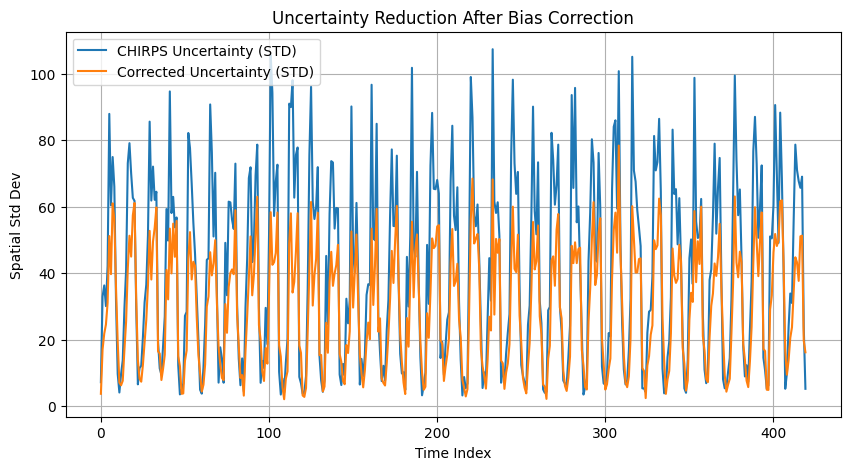

In [12]:
raw_std = []
corr_std = []

for raw_f, corr_f in zip(raw_files, corr_files):

    with rasterio.open(raw_f) as src:
        raw = src.read(1)

    with rasterio.open(corr_f) as src:
        corr = src.read(1)

    raw_std.append(np.nanstd(raw))
    corr_std.append(np.nanstd(corr))

plt.figure(figsize=(10,5))
plt.plot(raw_std, label="CHIRPS Uncertainty (STD)")
plt.plot(corr_std, label="Corrected Uncertainty (STD)")

plt.title("Uncertainty Reduction After Bias Correction")
plt.xlabel("Time Index")
plt.ylabel("Spatial Std Dev")
plt.legend()
plt.grid()
plt.show()